In [1]:
""" Log
5/9/26 ---- Test notebook for AAA_holo_interp over U at fixed t=1.0.
Using weak-coupling expansion data at small U and strong-coupling expansion data at large U, then interpolating with respect to U on [0, U_max].
"""

' Log\n5/9/26 ---- Test notebook for AAA_holo_interp over U at fixed t=1.0.\nUsing weak-coupling expansion data at small U and strong-coupling expansion data at large U, then interpolating with respect to U on [0, U_max].\n'

In [2]:
### Using AAA_holo_interp to interpolate G(U, t=1.0, iw_n).
import sys
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt
import analytic_solution as AS
import diff_G as diff
import utilities as ut
from _bary_rational import AAA_holo_interp

In [3]:
beta = 20.0
Ntau = 401
Ns = 2
Nw = 4 * int(beta)
Mat_fre = (2 * np.linspace(0, Nw - 1, Nw) + 1) * np.pi / beta
wn = np.append(-np.flip(Mat_fre), Mat_fre)   # w_n = (2n+1)*pi/beta

In [4]:
### Exact and perturbative data on the full U grid
t_fixed = 1.0
U_max = 50.0
NU = 1001
U_values_ED = np.linspace(0, U_max, NU)

interp_order = 6
test_order = interp_order + 1

Gij_iwn_exact = np.zeros((len(U_values_ED), wn.size, Ns, Ns), dtype="complex")
Gij_iwn_wce = np.zeros((test_order, len(U_values_ED), wn.size, Ns, Ns), dtype="complex")
Gij_iwn_sce = np.zeros((test_order, len(U_values_ED), wn.size, Ns, Ns), dtype="complex")

for u_idx, U in enumerate(U_values_ED):
    Gij_iwn_exact[u_idx] = AS.G_analytic(t_fixed, wn, U, beta)
    for order in range(test_order):
        Gij_iwn_wce[order, u_idx] = diff.Gij_wce_series(order, t_fixed, U, wn)
        Gij_iwn_sce[order, u_idx] = diff.Gij_sce_series(order, t_fixed, U, wn, beta)

/Users/yzhu4/Desktop/projects/rational_interpolation_hubbard/Many_body_interpolation/hubbard_dimer/U_interpolation/../diff_G.py:229: RuntimeWarning: divide by zero encountered in divide
  G5_ij[:,0,1] = num / den
/Users/yzhu4/Desktop/projects/rational_interpolation_hubbard/Many_body_interpolation/hubbard_dimer/U_interpolation/../diff_G.py:229: RuntimeWarning: invalid value encountered in divide
  G5_ij[:,0,1] = num / den
/Users/yzhu4/Desktop/projects/rational_interpolation_hubbard/Many_body_interpolation/hubbard_dimer/U_interpolation/../diff_G.py:364: RuntimeWarning: invalid value encountered in multiply
  Gn_ij = G0_ij_sce(wn, U, beta)+ t*G1_ij_sce(wn, U, beta) + t**2*G2_ij_sce(wn, U, beta)+ t**3*G3_ij_sce(wn, U, beta)+ t**4*G4_ij_sce(wn, U, beta)+ t**5*G5_ij_sce(wn, U, beta)
/Users/yzhu4/Desktop/projects/rational_interpolation_hubbard/Many_body_interpolation/hubbard_dimer/U_interpolation/../diff_G.py:366: RuntimeWarning: invalid value encountered in multiply
  Gn_ij = G0_ij_sce(wn, U

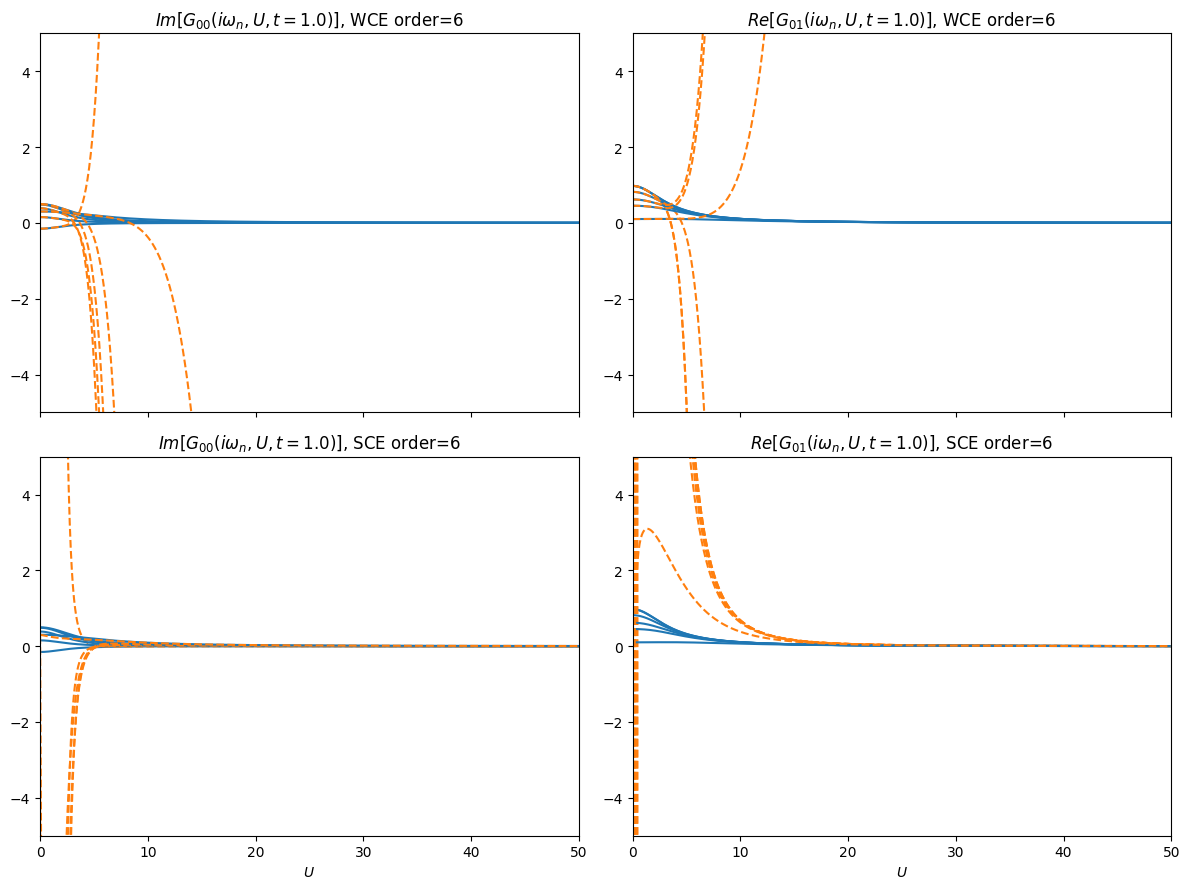

In [5]:
### Quick WCE/SCE comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=False)
(ax11, ax12), (ax21, ax22) = axes
wn_id = [Nw, Nw - 1, Nw - 2, Nw - 3, Nw - 4, Nw - 10]

for i in wn_id:
    ax11.plot(U_values_ED, Gij_iwn_exact[:, i, 0, 0].imag, "C0")
    ax11.plot(U_values_ED, Gij_iwn_wce[interp_order, :, i, 0, 0].imag, "C1--")
ax11.set_title(r"$Im[G_{00}(i\omega_n,U,t=%.1f)]$, WCE order=%d" % (t_fixed, interp_order))

for i in wn_id:
    ax12.plot(U_values_ED, Gij_iwn_exact[:, i, 0, 1].real, "C0")
    ax12.plot(U_values_ED, Gij_iwn_wce[interp_order, :, i, 0, 1].real, "C1--")
ax12.set_title(r"$Re[G_{01}(i\omega_n,U,t=%.1f)]$, WCE order=%d" % (t_fixed, interp_order))

for i in wn_id:
    ax21.plot(U_values_ED, Gij_iwn_exact[:, i, 0, 0].imag, "C0")
    ax21.plot(U_values_ED, Gij_iwn_sce[interp_order, :, i, 0, 0].imag, "C1--")
ax21.set_xlabel(r"$U$")
ax21.set_title(r"$Im[G_{00}(i\omega_n,U,t=%.1f)]$, SCE order=%d" % (t_fixed, interp_order))

for i in wn_id:
    ax22.plot(U_values_ED, Gij_iwn_exact[:, i, 0, 1].real, "C0")
    ax22.plot(U_values_ED, Gij_iwn_sce[interp_order, :, i, 0, 1].real, "C1--")
ax22.set_xlabel(r"$U$")
ax22.set_title(r"$Re[G_{01}(i\omega_n,U,t=%.1f)]$, SCE order=%d" % (t_fixed, interp_order))

for ax in axes.ravel():
    ax.set_xlim([0, U_max])
    ax.set_ylim([-5, 5])
fig.tight_layout()
plt.show()

In [14]:
### Constructing the interpolation data in U
N_wce = 501
U_wce_max = 2.0
print("The WCE U window is:", (0, U_wce_max))
U_wce = np.linspace(0, U_wce_max, N_wce)

G_wce = np.zeros((len(U_wce), wn.size, Ns, Ns), dtype="complex")
for i, U in enumerate(U_wce):
    G_wce[i] = diff.Gij_wce_series(interp_order, t_fixed, U, wn)

N_sce = 101
U_sce_min = 10.4
print("The SCE U window is:", (U_sce_min, U_max))
U_sce = np.linspace(U_sce_min, U_max, N_sce)

G_sce = np.zeros((len(U_sce), wn.size, Ns, Ns), dtype="complex")
for i, U in enumerate(U_sce):
    G_sce[i] = diff.Gij_sce_series(interp_order, t_fixed, U, wn, beta)

U_app = np.concatenate([U_wce, U_sce], axis=0)
G_app = np.concatenate([G_wce, G_sce], axis=0)
print(U_app.shape)
print(G_app.shape)

The WCE U window is: (0, 2.0)
The SCE U window is: (10.4, 50.0)
(602,)
(602, 160, 2, 2)


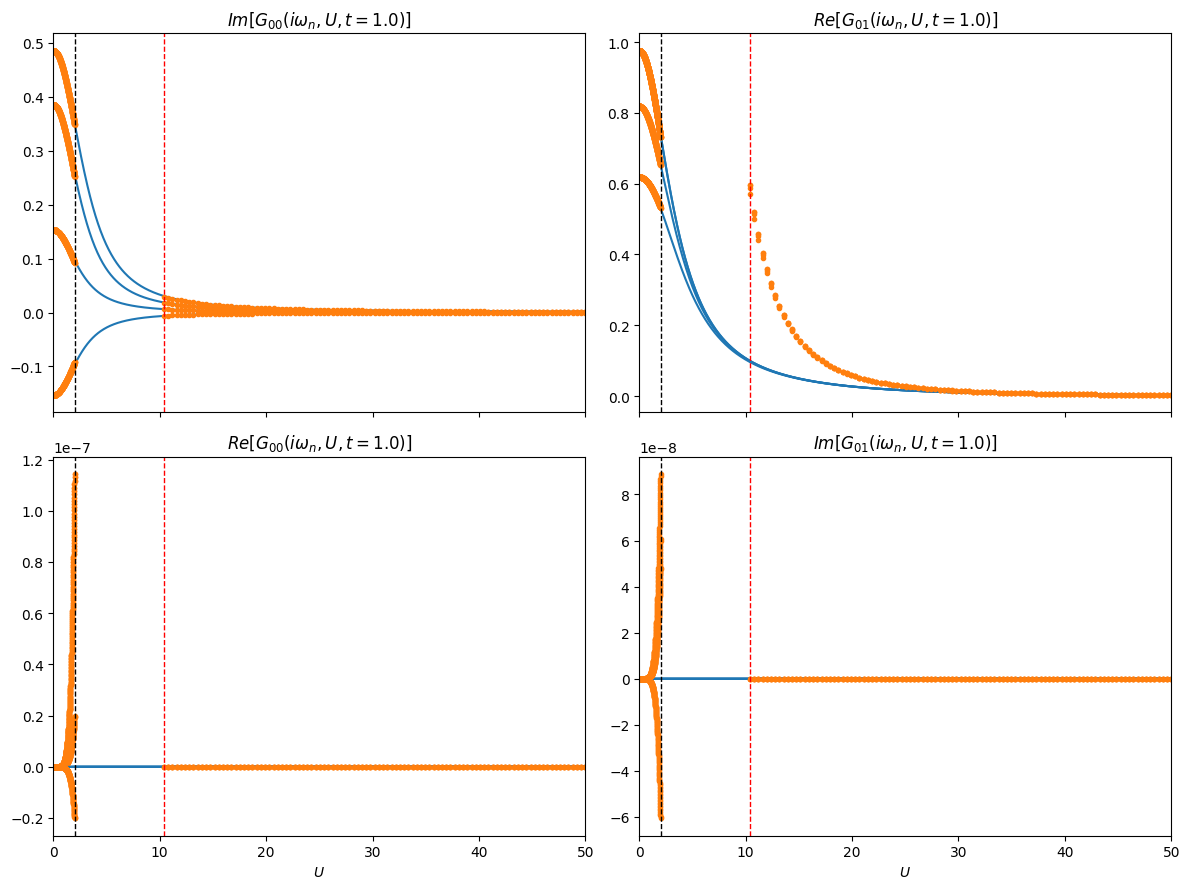

In [15]:
### Plot interpolation input data
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=False)
(ax11, ax12), (ax21, ax22) = axes
wn_id = [Nw, Nw - 1, Nw - 2, Nw - 3]

for i in wn_id:
    ax11.plot(U_values_ED, Gij_iwn_exact[:, i, 0, 0].imag, "C0")
    ax11.plot(U_app, G_app[:, i, 0, 0].imag, "C1.")
ax11.set_title(r"$Im[G_{00}(i\omega_n,U,t=%.1f)]$" % t_fixed)

for i in wn_id:
    ax12.plot(U_values_ED, Gij_iwn_exact[:, i, 0, 1].real, "C0")
    ax12.plot(U_app, G_app[:, i, 0, 1].real, "C1.")
ax12.set_title(r"$Re[G_{01}(i\omega_n,U,t=%.1f)]$" % t_fixed)

for i in wn_id:
    ax21.plot(U_values_ED, Gij_iwn_exact[:, i, 0, 0].real, "C0")
    ax21.plot(U_app, G_app[:, i, 0, 0].real, "C1.")
ax21.set_xlabel(r"$U$")
ax21.set_title(r"$Re[G_{00}(i\omega_n,U,t=%.1f)]$" % t_fixed)

for i in wn_id:
    ax22.plot(U_values_ED, Gij_iwn_exact[:, i, 0, 1].imag, "C0")
    ax22.plot(U_app, G_app[:, i, 0, 1].imag, "C1.")
ax22.set_xlabel(r"$U$")
ax22.set_title(r"$Im[G_{01}(i\omega_n,U,t=%.1f)]$" % t_fixed)

for ax in axes.ravel():
    ax.axvline(U_wce_max, color="k", linestyle="--", linewidth=1)
    ax.axvline(U_sce_min, color="r", linestyle="--", linewidth=1)
    ax.set_xlim([0, U_max])
fig.tight_layout()
plt.show()

In [8]:
### AAA interpolation in U
err_bar1 = 1e-3
max_trials = 100
max_terms = 10
perturbation_magnitude = err_bar1
pole_real_window = (U_wce_max, U_sce_min)

G01_interp = np.zeros((U_values_ED.size, wn.size), dtype=complex)
G00_interp = np.zeros((U_values_ED.size, wn.size), dtype=complex)

for n in range(wn.size):
    print("n=", n)
    r00 = AAA_holo_interp(
        U_app, G_app[:, n, 0, 0], rtol=err_bar1, max_terms=max_terms,
        pole_real_window=pole_real_window, max_trials=max_trials,
        perturbation_magnitude=perturbation_magnitude,
    )
    G00_interp[:, n] = r00(U_values_ED.real)

    r01 = AAA_holo_interp(
        U_app, G_app[:, n, 0, 1], rtol=err_bar1, max_terms=max_terms,
        pole_real_window=pole_real_window, max_trials=max_trials,
        perturbation_magnitude=perturbation_magnitude,
    )
    G01_interp[:, n] = r01(U_values_ED.real)

n= 0
AAA_holo_interp final max_error: 0.0077266868073511815
AAA_holo_interp perturbation_magnitude: 0.001
AAA_holo_interp perturbation_trials: 2
AAA_holo_interp accepted a perturbed interpolation
n= 1
AAA_holo_interp final max_error: 0.002291531503516408
AAA_holo_interp perturbation_magnitude: 0.001
AAA_holo_interp perturbation_trials: 1
AAA_holo_interp accepted a perturbed interpolation
n= 2
AAA_holo_interp final max_error: 0.0038797583367685797
AAA_holo_interp perturbation_magnitude: 0.001
AAA_holo_interp perturbation_trials: 2
AAA_holo_interp accepted a perturbed interpolation
n= 3
AAA_holo_interp final max_error: 0.005616308257161607
AAA_holo_interp perturbation_magnitude: 0.001
AAA_holo_interp perturbation_trials: 1
AAA_holo_interp accepted a perturbed interpolation
n= 4
AAA_holo_interp final max_error: 0.011184888626096307
AAA_holo_interp perturbation_magnitude: 0.001
AAA_holo_interp perturbation_trials: 2
AAA_holo_interp accepted a perturbed interpolation
n= 5
AAA_holo_interp fi

n = 80 omega = 0.15707963267948966
n = 79 omega = -0.15707963267948966
n = 78 omega = -0.47123889803846897
n = 77 omega = -0.7853981633974483
n = 76 omega = -1.0995574287564276
n = 70 omega = -2.9845130209103035


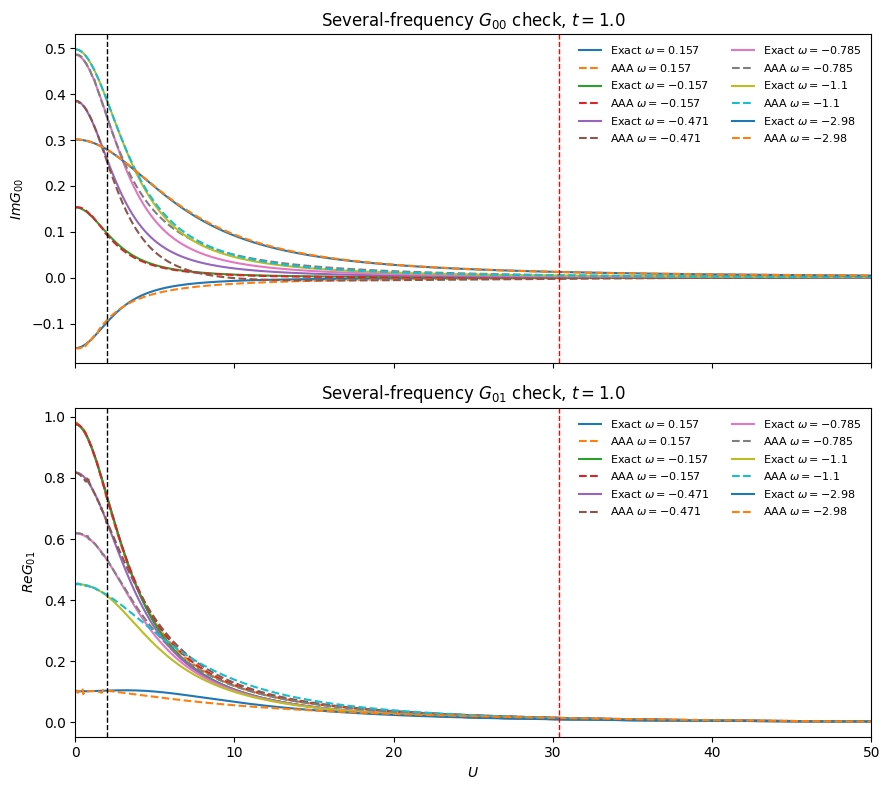

In [9]:
### Several-frequency check
wn_id = [Nw, Nw - 1, Nw - 2, Nw - 3, Nw - 4, Nw - 10]
fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

for n in wn_id:
    print("n =", n, "omega =", wn[n])
    axes[0].plot(U_values_ED, Gij_iwn_exact[:, n, 0, 0].imag, label=rf"Exact $\omega={wn[n]:.3g}$")
    axes[0].plot(U_values_ED, G00_interp[:, n].imag, "--", label=rf"AAA $\omega={wn[n]:.3g}$")

    axes[1].plot(U_values_ED, Gij_iwn_exact[:, n, 0, 1].real, label=rf"Exact $\omega={wn[n]:.3g}$")
    axes[1].plot(U_values_ED, G01_interp[:, n].real, "--", label=rf"AAA $\omega={wn[n]:.3g}$")

axes[0].set_ylabel(r"$Im G_{00}$")
axes[0].set_title(r"Several-frequency $G_{00}$ check, $t=%.1f$" % t_fixed)
axes[1].set_ylabel(r"$Re G_{01}$")
axes[1].set_xlabel(r"$U$")
axes[1].set_title(r"Several-frequency $G_{01}$ check, $t=%.1f$" % t_fixed)

for ax in axes:
    ax.axvline(U_wce_max, color="k", linestyle="--", linewidth=1)
    ax.axvline(U_sce_min, color="r", linestyle="--", linewidth=1)
    ax.set_xlim([0, U_max])
    ax.legend(frameon=False, ncol=2, fontsize=8)

fig.tight_layout()
plt.show()

frequency = 0.15707963267948966
frequency = -0.15707963267948966
frequency = -0.47123889803846897
frequency = -0.7853981633974483
frequency = -1.0995574287564276


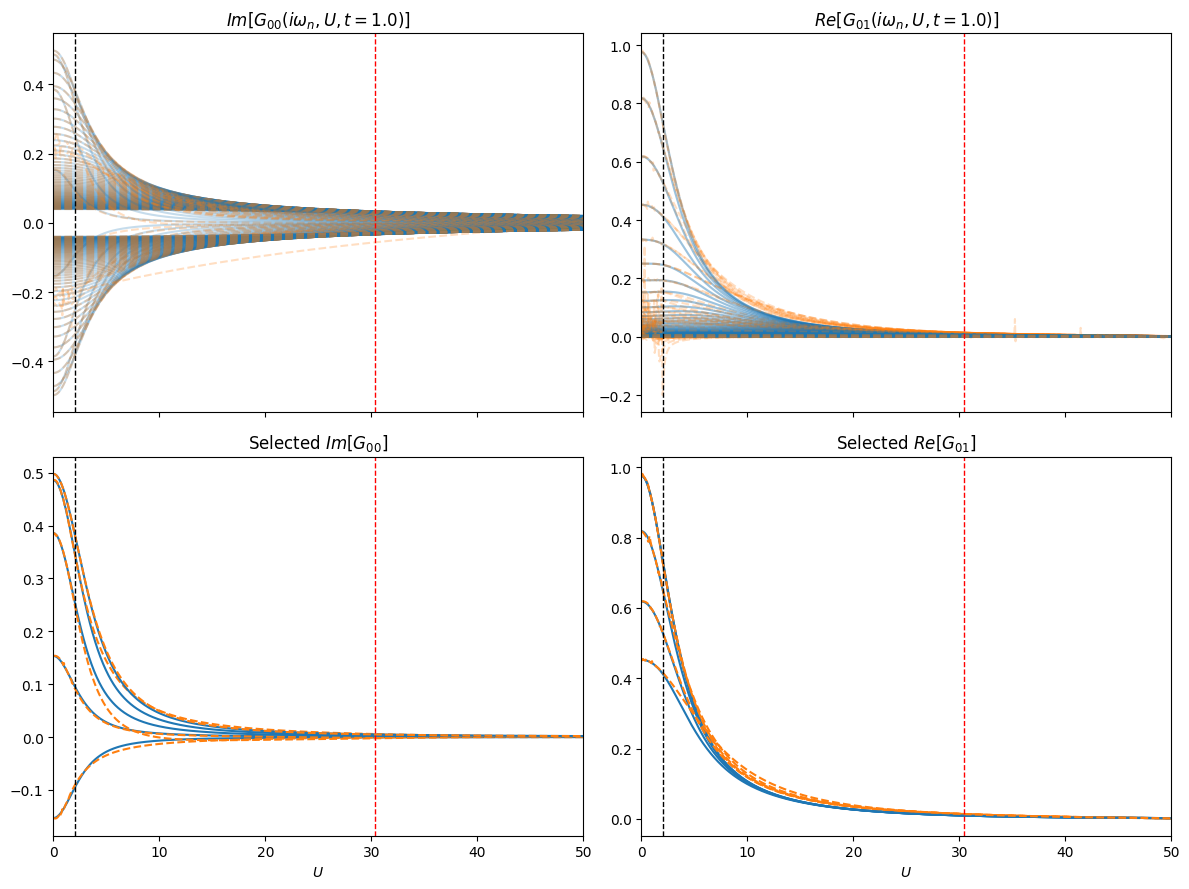

In [10]:
### Summary plots
fig, ax = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=False)
wn_id = [Nw, Nw - 1, Nw - 2, Nw - 3, Nw - 4]

for i in range(wn.size):
    ax[0, 0].plot(U_values_ED, Gij_iwn_exact[:, i, 0, 0].imag, "C0", alpha=0.25)
    ax[0, 0].plot(U_values_ED, G00_interp[:, i].imag, "C1--", alpha=0.25)
ax[0, 0].set_title(r"$Im[G_{00}(i\omega_n,U,t=%.1f)]$" % t_fixed)

for i in range(wn.size):
    ax[0, 1].plot(U_values_ED, Gij_iwn_exact[:, i, 0, 1].real, "C0", alpha=0.25)
    ax[0, 1].plot(U_values_ED, G01_interp[:, i].real, "C1--", alpha=0.25)
ax[0, 1].set_title(r"$Re[G_{01}(i\omega_n,U,t=%.1f)]$" % t_fixed)

for i in wn_id:
    print("frequency =", wn[i])
    ax[1, 0].plot(U_values_ED, Gij_iwn_exact[:, i, 0, 0].imag, "C0")
    ax[1, 0].plot(U_values_ED, G00_interp[:, i].imag, "C1--")
ax[1, 0].set_xlabel(r"$U$")
ax[1, 0].set_title(r"Selected $Im[G_{00}]$")

for i in wn_id:
    ax[1, 1].plot(U_values_ED, Gij_iwn_exact[:, i, 0, 1].real, "C0")
    ax[1, 1].plot(U_values_ED, G01_interp[:, i].real, "C1--")
ax[1, 1].set_xlabel(r"$U$")
ax[1, 1].set_title(r"Selected $Re[G_{01}]$")

for a in ax.ravel():
    a.axvline(U_wce_max, color="k", linestyle="--", linewidth=1)
    a.axvline(U_sce_min, color="r", linestyle="--", linewidth=1)
    a.set_xlim([0, U_max])
fig.tight_layout()
plt.show()

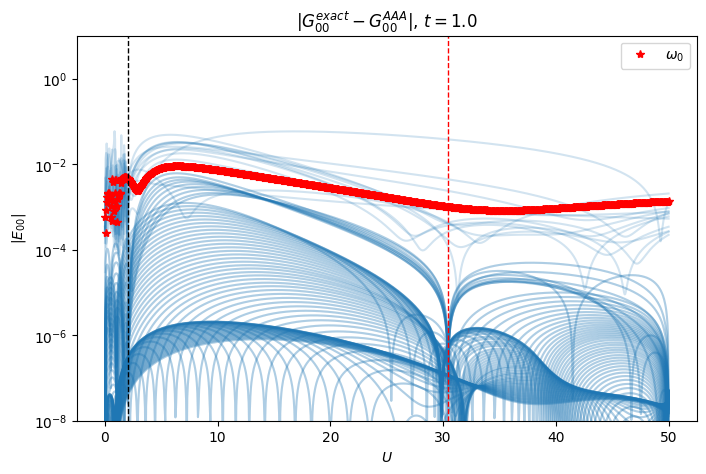

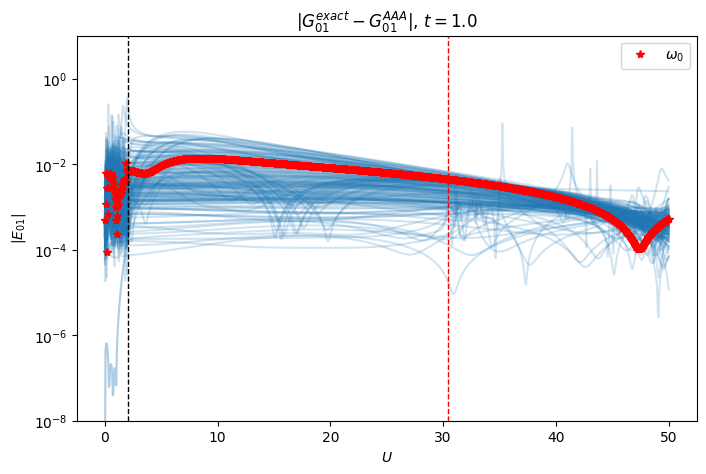

In [11]:
### Error plots
wn_id = [Nw, Nw - 1, Nw - 2, Nw - 3, Nw - 4, Nw - 10]

plt.figure(figsize=(8, 5))
for i in range(wn.size):
    plt.semilogy(U_values_ED, np.abs(Gij_iwn_exact[:, i, 0, 0] - G00_interp[:, i]), "C0", alpha=0.2)
plt.semilogy(U_values_ED, np.abs(Gij_iwn_exact[:, Nw, 0, 0] - G00_interp[:, Nw]), "r*", label=r"$\omega_0$")
plt.axvline(U_wce_max, color="k", linestyle="--", linewidth=1)
plt.axvline(U_sce_min, color="r", linestyle="--", linewidth=1)
plt.xlabel(r"$U$")
plt.ylabel(r"$|E_{00}|$")
plt.title(r"$|G_{00}^{exact} - G_{00}^{AAA}|$, $t=%.1f$" % t_fixed)
plt.ylim([1e-8, 10])
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for i in range(wn.size):
    plt.semilogy(U_values_ED, np.abs(Gij_iwn_exact[:, i, 0, 1] - G01_interp[:, i]), "C0", alpha=0.2)
plt.semilogy(U_values_ED, np.abs(Gij_iwn_exact[:, Nw, 0, 1] - G01_interp[:, Nw]), "r*", label=r"$\omega_0$")
plt.axvline(U_wce_max, color="k", linestyle="--", linewidth=1)
plt.axvline(U_sce_min, color="r", linestyle="--", linewidth=1)
plt.xlabel(r"$U$")
plt.ylabel(r"$|E_{01}|$")
plt.title(r"$|G_{01}^{exact} - G_{01}^{AAA}|$, $t=%.1f$" % t_fixed)
plt.ylim([1e-8, 10])
plt.legend()
plt.show()

In [13]:
print("This runs")
# raise SystemExit

### Optional imaginary-time transform checks after this point
Ed_end = int(NU / 2)
Ed_gap = max(1, int(NU / 50))
tau = np.linspace(0, beta, Ntau)
Test_U = U_values_ED[0:Ed_end:Ed_gap]

print("The test Us are:", Test_U)
G01_iwn_exact_CG = Gij_iwn_exact[0:Ed_end:Ed_gap, :, 0, 1]
G00_iwn_exact_CG = Gij_iwn_exact[0:Ed_end:Ed_gap, :, 0, 0]
G01_iwn_interp_CG = G01_interp[0:Ed_end:Ed_gap, :]
G00_iwn_interp_CG = G00_interp[0:Ed_end:Ed_gap, :]

Gij_iwn_exact_CG = np.zeros((len(Test_U), wn.size, Ns, Ns), dtype="complex")
Gij_iwn_interp_CG = np.zeros((len(Test_U), wn.size, Ns, Ns), dtype="complex")

Gij_iwn_interp_CG[:, :, 1, 1] = G00_iwn_interp_CG
Gij_iwn_interp_CG[:, :, 1, 0] = G01_iwn_interp_CG
Gij_iwn_interp_CG[:, :, 0, 0] = G00_iwn_interp_CG
Gij_iwn_interp_CG[:, :, 0, 1] = G01_iwn_interp_CG

Gij_iwn_exact_CG[:, :, 1, 1] = G00_iwn_exact_CG
Gij_iwn_exact_CG[:, :, 1, 0] = G01_iwn_exact_CG
Gij_iwn_exact_CG[:, :, 0, 0] = G00_iwn_exact_CG
Gij_iwn_exact_CG[:, :, 0, 1] = G01_iwn_exact_CG

Gij_tau_exact_CG = np.zeros((len(Test_U), Ntau, Ns, Ns))
Gij_tau_interp_CG = np.zeros((len(Test_U), Ntau, Ns, Ns))

for i in range(len(Test_U)):
    Gij_tau_exact_CG[i] = np.real(ut.Gij_iwn_to_Gij_tau(Gij_iwn_exact_CG[i], wn, tau, beta))
    Gij_tau_interp_CG[i] = np.real(ut.Gij_iwn_to_Gij_tau(Gij_iwn_interp_CG[i], wn, tau, beta))

This runs
The test Us are: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24.]
